In [110]:
import pandas as pd
import matplotlib.pyplot as plt

In [112]:
def plot_comparison(comparison_dfs, output_path="thesis_comparison.png"):
    # Load data
    for file_name, df in comparison_dfs.items():
        comparison_dfs[file_name] = pd.read_csv(df)
    
    fig, axs = plt.subplots(3, 1, figsize=(12, 14))
    
    # 1. Waiting Time Comparison (The Performance Metric)
    for file_name, df in comparison_dfs.items():
        display(df.head())
        axs[0].plot(df['step'], df['avg_waiting_time'].rolling(window=10).mean(), label=file_name)
    
    axs[0].set_title("Average System Waiting Time (Lower is Better)")
    axs[0].legend()

    # 2. Value Function V(s) (The Confidence Metric)
    for file_name, df in comparison_dfs.items():
        axs[1].plot(df['step'], df['value_estimate'], label=file_name)
    
    axs[1].set_title("State Value Estimate (Agent's Internal Evaluation)")
    axs[1].legend()

    # ---------------------------------------------------------
    # Chart 1: Average Waiting Time PER EPISODE (Learning Curve)
    # ---------------------------------------------------------
    # Group the data by episode and calculate the mean waiting time for the entire hour
    episode_avg_dfs = {}
    for file_name, df in comparison_dfs.items():
        episode_avg_dfs[file_name] = df.groupby("episode")['avg_waiting_time'].mean()

        axs[2].plot(episode_avg_dfs[file_name].index, episode_avg_dfs[file_name].values, marker='o', linewidth=2, label=file_name)
    
    # axs[2].plot(ep_avg2.index, ep_avg2.values, marker='o', linewidth=2, label=file2_name)
    axs[2].set_title('Average Waiting Time per Episode (The Learning Curve)')
    axs[2].set_xlabel('Episode Number', fontsize=8)
    axs[2].set_ylabel('Average Waiting Time (s)', fontsize=8)
    axs[2].grid(True, linestyle='--', alpha=0.7)
    axs[2].legend()
    # axs[2].set_ylim(0, 1.5)
    plt.tight_layout()
    plt.savefig(output_path)
    plt.show()

,episode,step,value_estimate,optimum_action,reward,avg_waiting_time,total_stopped,co2_emissions,actual_action
0,1,10,0.043504,1,0.12,0.206897,1,0,0
1,1,20,0.051498,1,-0.24,2.266667,8,0,1
2,1,30,0.037200,1,0.07,0.777778,8,0,1
3,1,40,0.100255,0,-0.32,0.860465,8,0,0
4,1,50,0.097305,0,-0.22,0.575000,7,0,1


,episode,step,value_estimate,optimum_action,reward,avg_waiting_time,total_stopped,co2_emissions,actual_action
0,1,10,0.118793,1,0.22,0.500000,2,0,1
1,1,20,0.118055,1,-0.12,1.333333,4,0,1
2,1,30,0.119670,1,0.09,0.473684,2,0,1
3,1,40,0.118055,1,-0.13,1.238095,4,0,1
4,1,50,0.133872,1,0.18,0.000000,0,0,0


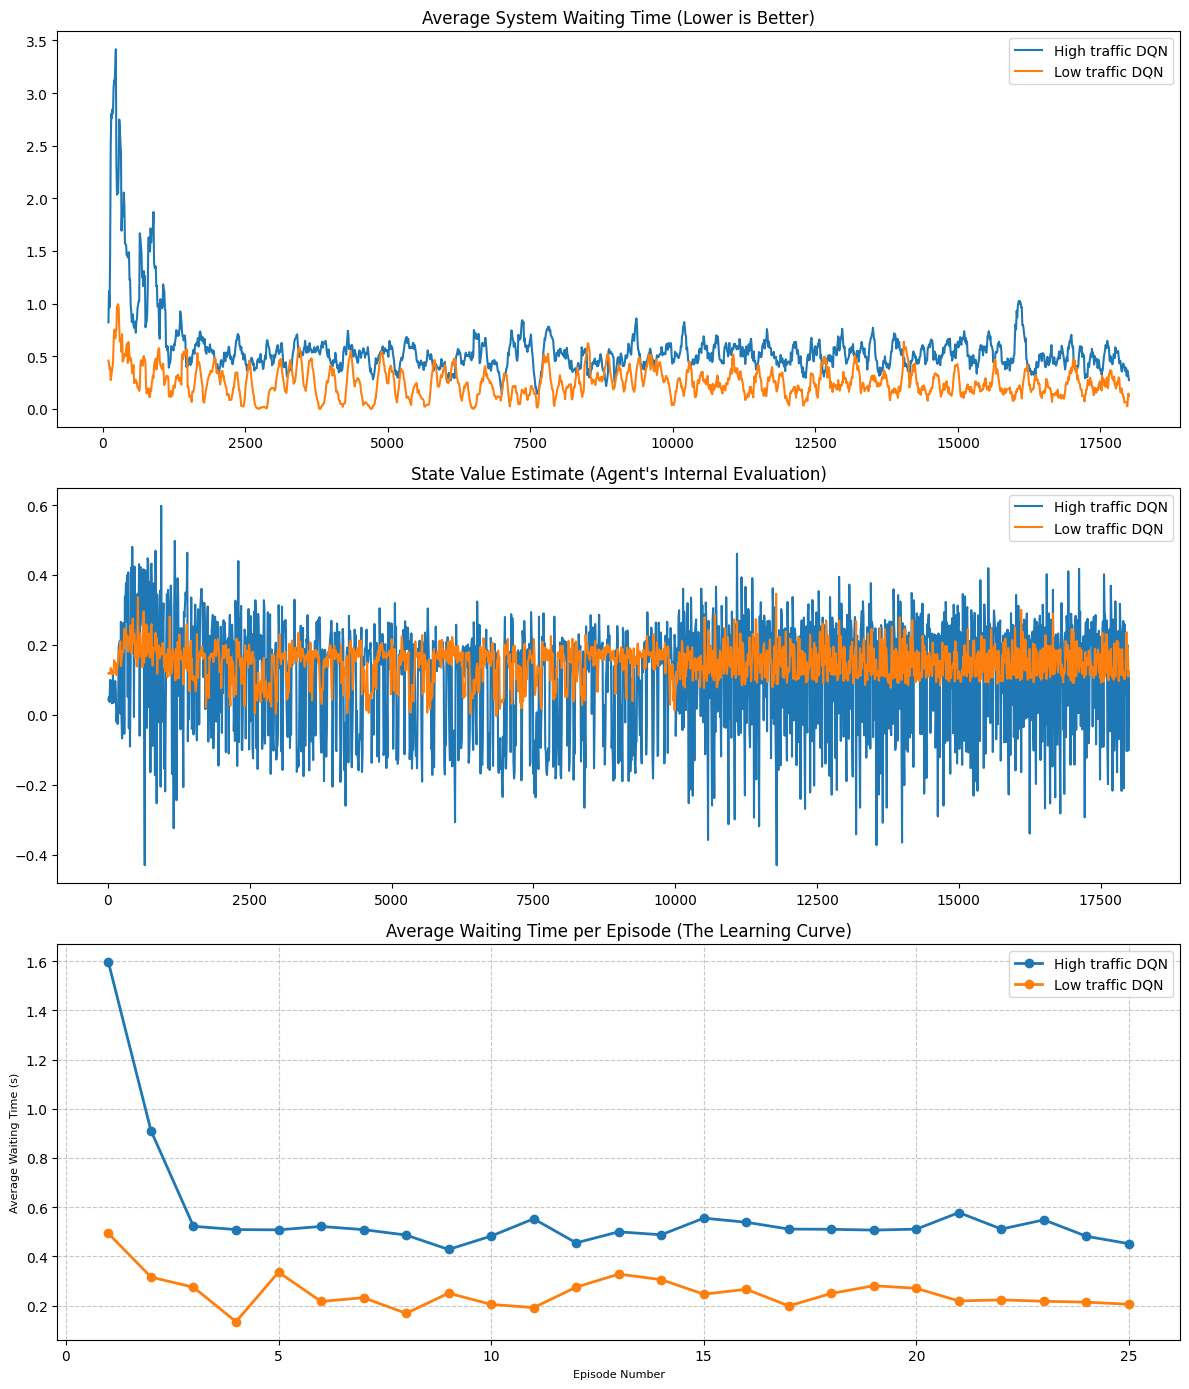

In [114]:
comparison_dfs = {
    "High traffic DQN": "results/results_DQN_high_traffic.csv",
    "Low traffic DQN": "results/results_DQN_low_traffic.csv"
}

plot_comparison(comparison_dfs, "results/high_vs_low_traffic_steady_traffic_dqn.png")

,episode,step,value_estimate,optimum_action,reward,avg_waiting_time,total_stopped,co2_emissions,actual_action
0,1,10,-0.005048,0,0.22,0.450000,6,0,1
1,1,20,0.015572,0,-0.27,0.937500,17,0,1
2,1,30,0.040026,0,-0.28,0.477612,12,0,1
3,1,40,0.040727,0,0.16,0.739130,14,0,1
4,1,50,0.018776,0,0.04,4.671875,31,0,1


,episode,step,value_estimate,optimum_action,reward,avg_waiting_time,total_stopped,co2_emissions,actual_action
0,1,10,-0.861586,1,-0.27,3.609756,14,0,0
1,1,20,-1.116992,0,0.15,1.839286,18,0,0
2,1,30,-2.162163,0,0.28,1.227273,14,0,1
3,1,40,-1.886235,1,-0.29,0.808824,19,0,0
4,1,50,-1.465522,0,-0.09,1.294118,15,0,0


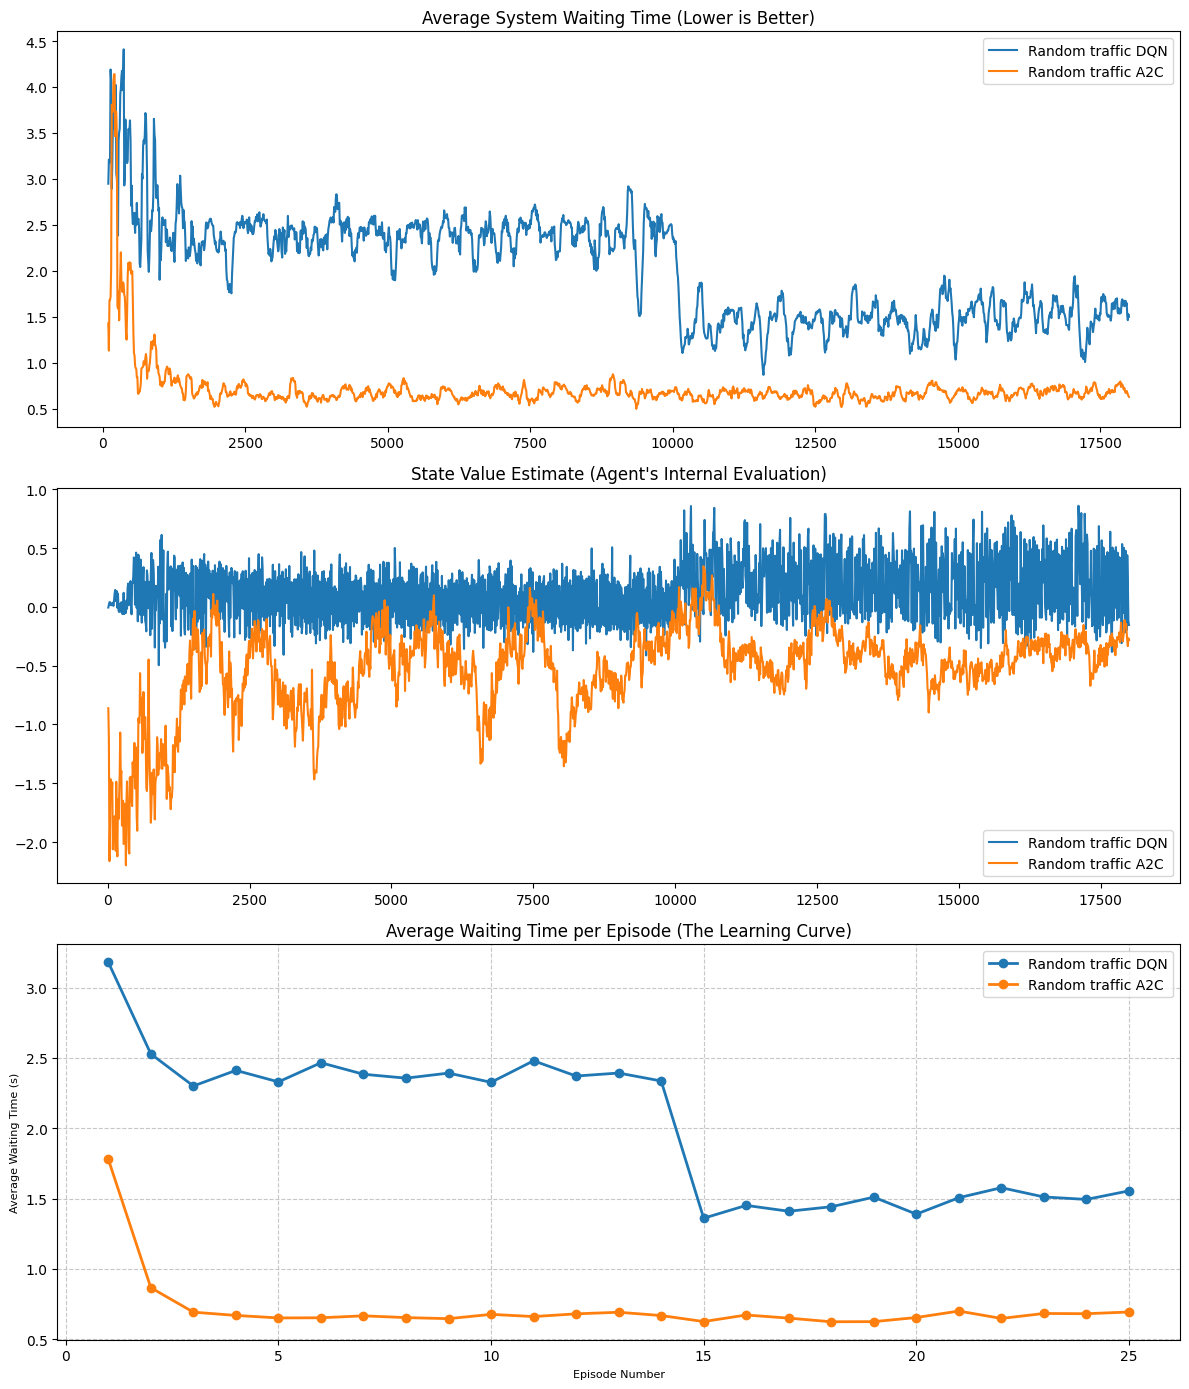

In [129]:
comparison_dfs = {
    "Random traffic DQN": "results/results_DQN_adaptative_random.csv",
    "Random traffic A2C": "results/results_A2C_adaptative_random.csv"
}

plot_comparison(comparison_dfs)

In [120]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_learning_progress(csv_file, model_description):
    print(f"Loading data from {csv_file}...")
    df = pd.read_csv(csv_file)
    
    # --- Data Preparation ---
    # Your CSV logs total steps (n_calls). We need to convert that into 
    # "Step within Episode" so all episodes start at 0 on the X-axis for charts 2 & 3.
    df['step_in_episode'] = df.groupby('episode')['step'].transform(lambda x: x - x.min())

    # NEW: Transform steps to seconds
    DELTA_TIME = 5
    df['seconds_in_episode'] = df['step_in_episode'] * DELTA_TIME
    
    # Set up the 3-panel figure
    fig, axs = plt.subplots(2, 1, figsize=(12, 10), sharey=True, sharex=True)

    # ---------------------------------------------------------
    # Chart 2: Intra-Episode Dynamics for FIRST 10 EPISODES
    # ---------------------------------------------------------
    first_episodes = df[df['episode'] <= 5]
    
    for ep in range(1, 6):
        ep_data = first_episodes[first_episodes['episode'] == ep]
        if not ep_data.empty:
            axs[0].plot(ep_data['seconds_in_episode'], ep_data['avg_waiting_time'], label=f'Ep {ep}', alpha=0.7)
            
    axs[0].set_title('First 5 Episodes (High Exploration / Poor Performance)')
    axs[0].set_xlabel('Seconds within Episode', fontsize=8)
    # axs[0].set_ylim(0, 12)
    axs[0].set_ylabel('Average Waiting Time (s)', fontsize=8)
    # axs[1].axvspan(1000, 2500, color='red', alpha=0.1, label='Traffic Spike')
    axs[0].legend(loc='center left', bbox_to_anchor=(1, 0.5), title="Episodes")
    axs[0].grid(True, linestyle='--', alpha=0.7)

    # ---------------------------------------------------------
    # Chart 3: Intra-Episode Dynamics for LAST 10 EPISODES
    # ---------------------------------------------------------
    total_episodes = df['episode'].max()
    last_10 = df[df['episode'] > total_episodes - 5]
    
    for ep in range(total_episodes - 4, total_episodes + 1):
        ep_data = last_10[last_10['episode'] == ep]
        if not ep_data.empty:
            axs[1].plot(ep_data['seconds_in_episode'], ep_data['avg_waiting_time'], label=f'Ep {ep}', alpha=0.7)
            
    axs[1].set_title(f'Last 5 Episodes (Exploitation / Converged Policy)')
    axs[1].set_xlabel('Seconds within Episode', fontsize=8)
    # axs[1].set_ylim(0, 12)
    axs[1].set_ylabel('Average Waiting Time (s)', fontsize=8)
    # axs[2].axvspan(1000, 2500, color='red', alpha=0.1, label='Traffic Spike')
    axs[1].legend(loc='center left', bbox_to_anchor=(1, 0.5), title="Episodes")

    axs[1].grid(True, linestyle='--', alpha=0.7)

    # Save and display
    # plt.tight_layout()

    output_image = f"{model_description}_learning_curve_analysis.png".lower()
    fig.suptitle(model_description.replace("_", " "))
    plt.savefig(output_image, bbox_inches='tight', dpi=150)
    print(f"✅ Success! Plot saved as {output_image}")
    plt.show()

Loading data from results/results_DQN_low_traffic.csv...
✅ Success! Plot saved as results/low_traffic_dqn_learning_curve_analysis.png


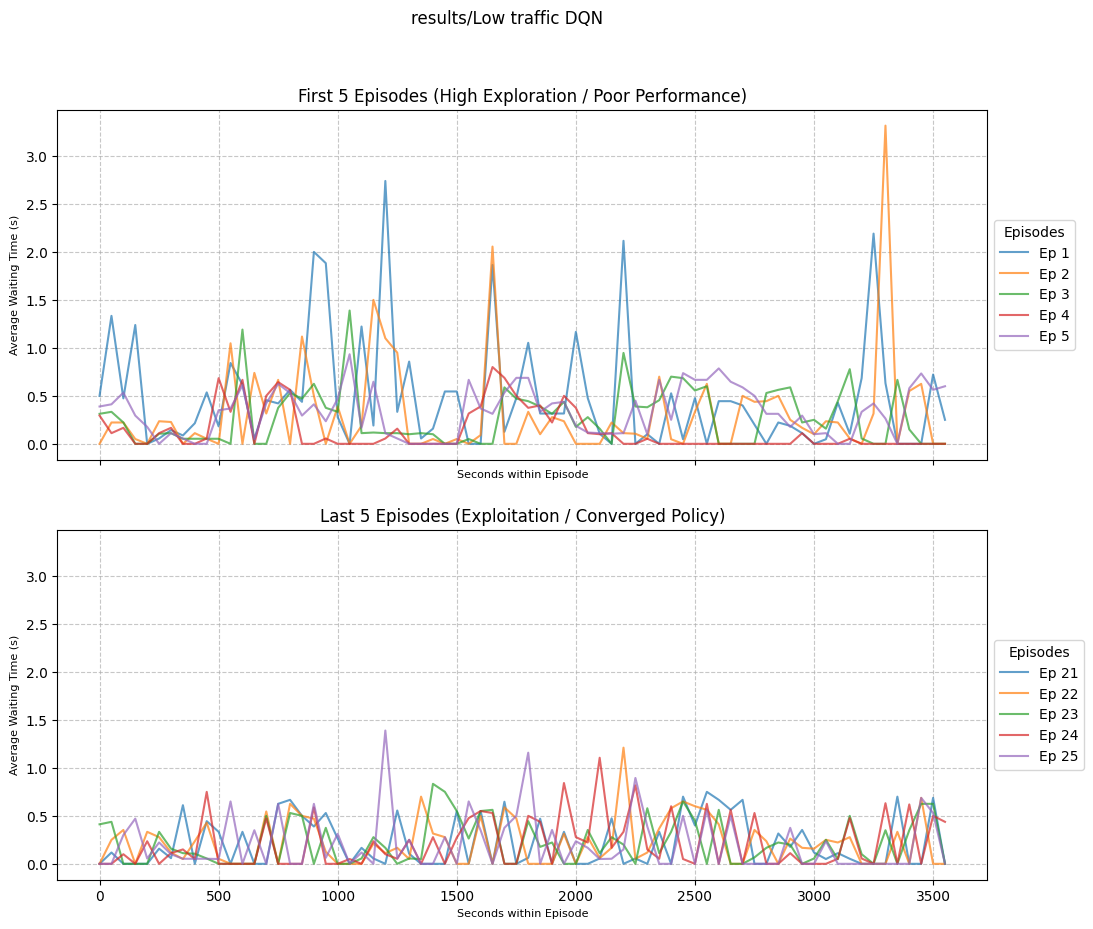

In [122]:

# Run the function on your newly generated CSV:
# Make sure to replace this with your actual CSV filename!
plot_learning_progress('results/results_DQN_low_traffic.csv', "results/Low_traffic_DQN")

Loading data from results/results_DQN_high_traffic.csv...
✅ Success! Plot saved as results/high_traffic_dqn_learning_curve_analysis.png


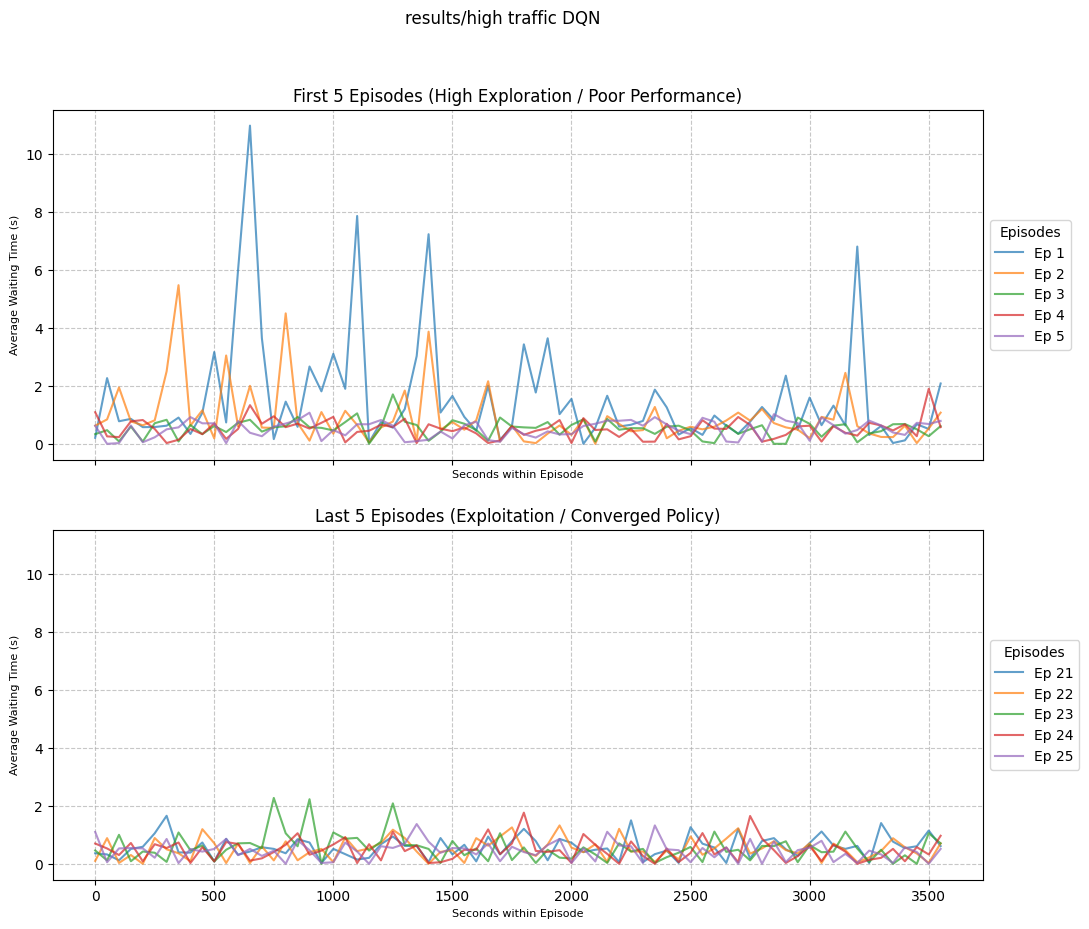

In [123]:
plot_learning_progress('results/results_DQN_high_traffic.csv', "results/high_traffic_DQN")

Loading data from results/results_DQN_adaptative_random.csv...
✅ Success! Plot saved as results/adaptative_random_dqn_learning_curve_analysis.png


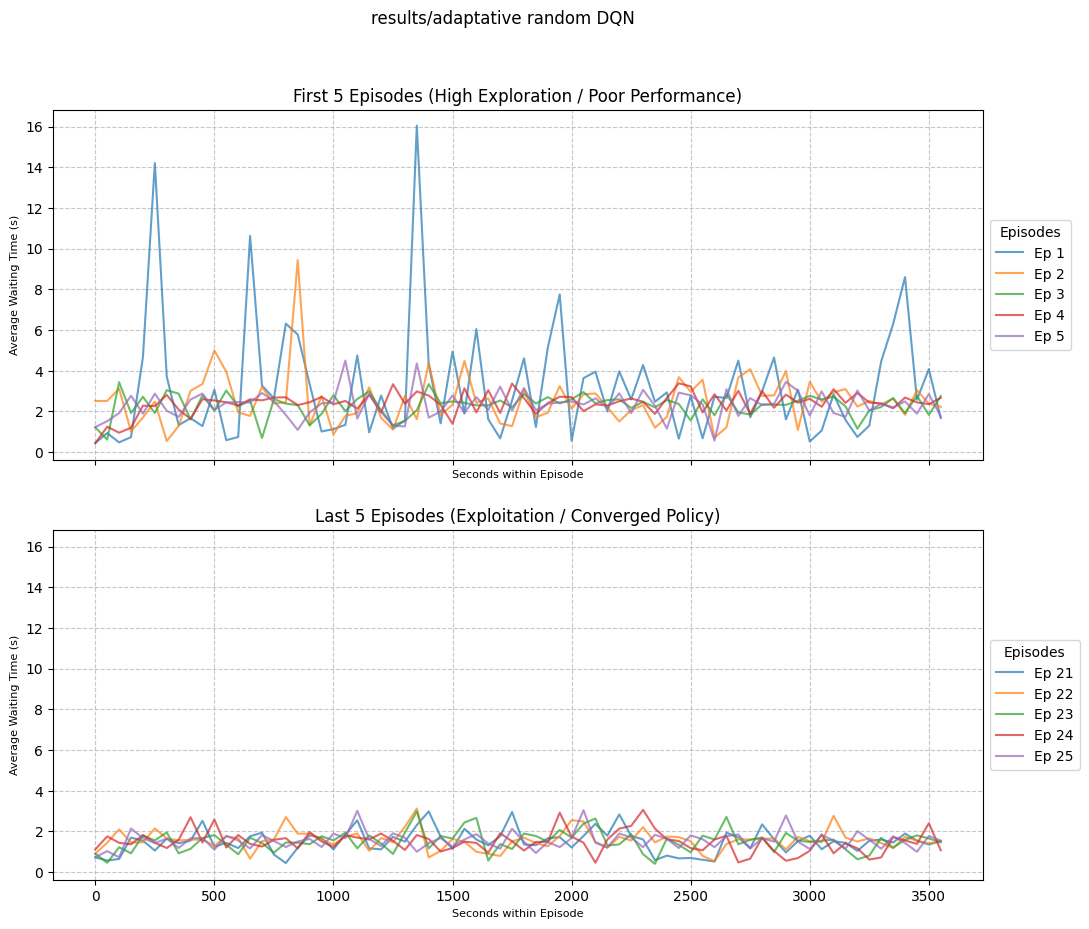

In [130]:
plot_learning_progress('results/results_DQN_adaptative_random.csv', "results/adaptative_random_DQN")

Loading data from results/results_A2C_adaptative_random.csv...
✅ Success! Plot saved as results/adaptative_random_a2c_learning_curve_analysis.png


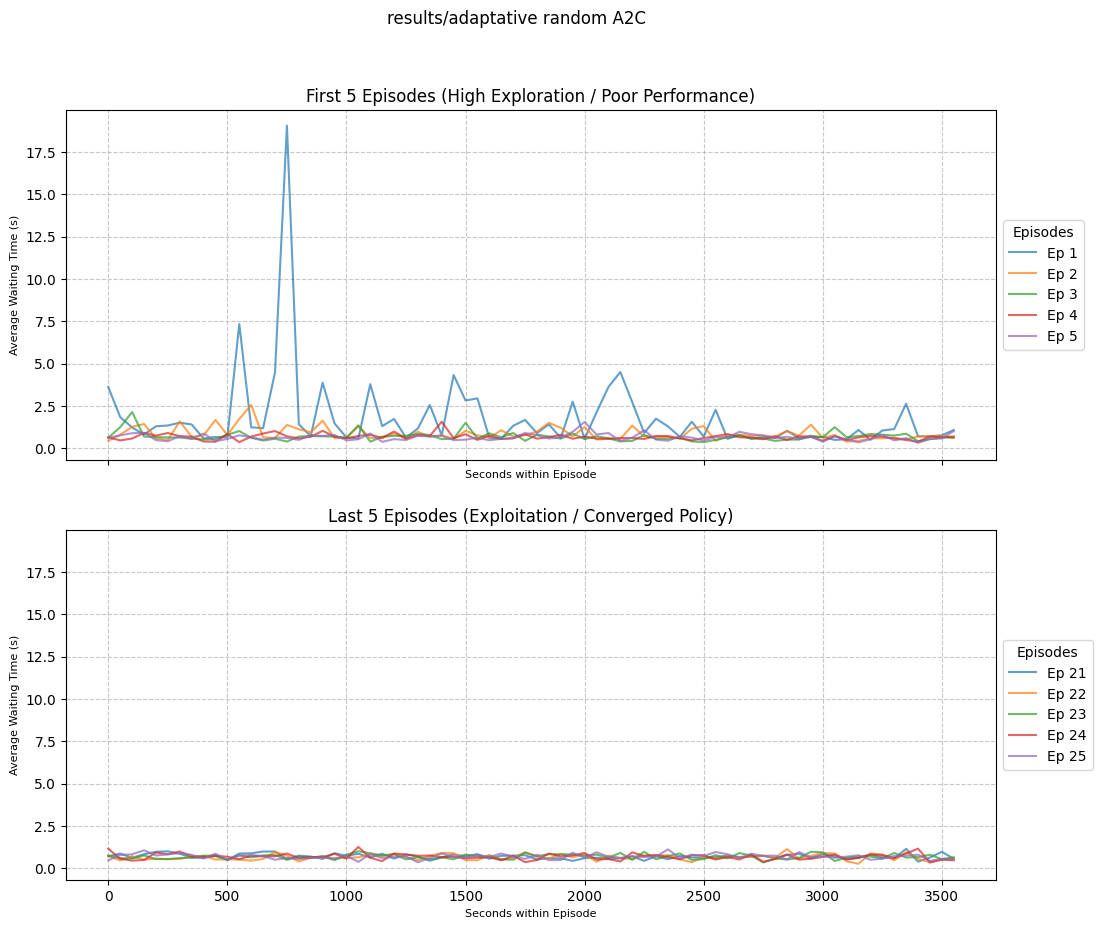

In [131]:
plot_learning_progress('results/results_A2C_adaptative_random.csv', "results/adaptative_random_A2C")

In [142]:

import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import A2C, DQN # Import both to be safe

def plot_decision_boundary(model_file, model_name, output_path, algo_type="A2C"):
    # 1. Dynamically select the correct class for loading
    if algo_type.upper() == "A2C":
        from stable_baselines3 import A2C
        model = A2C.load(model_file)
    elif algo_type.upper() == "DQN":
        from stable_baselines3 import DQN
        model = DQN.load(model_file)

    # 2. Define the grid (X = NS density, Y = EW density)
    density_range = np.linspace(0, 1.0, 50)
    ns_mesh, ew_mesh = np.meshgrid(density_range, density_range)
    action_matrix = np.zeros(ns_mesh.shape)

    # 3. Fill the grid with model predictions
    for i in range(ns_mesh.shape[0]):
        for j in range(ns_mesh.shape[1]):
            # Create dummy observation based on your sumo-rl mapping
            dummy_obs = np.zeros(obs_size)
            
            # Phase Mapping (Index 0-3 usually one-hot)
            # We assume current state is "NS Green" to see when it wants to switch
            dummy_obs[0] = 1 
            
            # Density Mapping (SUMO-RL default: 4=N, 5=E, 6=S, 7=W)
            dummy_obs[4] = ns_mesh[i, j] # North
            dummy_obs[6] = ns_mesh[i, j] # South
            dummy_obs[5] = ew_mesh[i, j] # East
            dummy_obs[7] = ew_mesh[i, j] # West
            
            # A2C predict uses the same syntax as DQN
            # deterministic=True is critical here to get the 'best' action 
            # instead of a random sample from the probability distribution
            action, _ = model.predict(dummy_obs, deterministic=True)
            action_matrix[i, j] = action

    # 4. Plotting
    plt.figure(figsize=(6, 4))
    
    # Use contourf to draw the regions
    plt.contourf(ns_mesh, ew_mesh, action_matrix, levels=[-0.5, 0.5, 1.5], 
                 colors=['blue', 'orange'], alpha=0.8)

    # Styling
    plt.xlabel("North-South Density (Avg of N and S lanes)")
    plt.ylabel("East-West Density (Avg of E and W lanes)")
    plt.title(f"{model_name} Policy Decision Boundary")

    # Legend / Colorbar
    cbar = plt.colorbar(ticks=[0, 1])
    cbar.set_ticklabels(['NS Green', 'EW Green'])

    plt.savefig(output_path, bbox_inches='tight', dpi=150)
    plt.show()

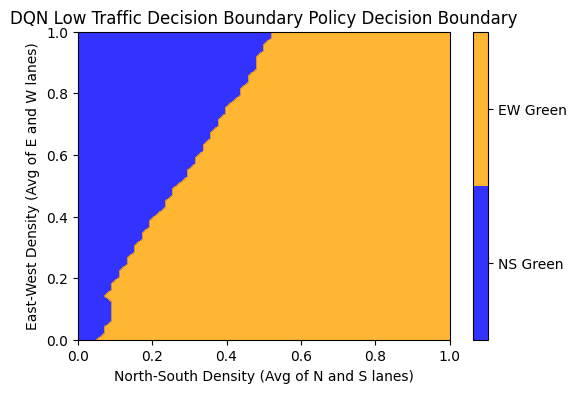

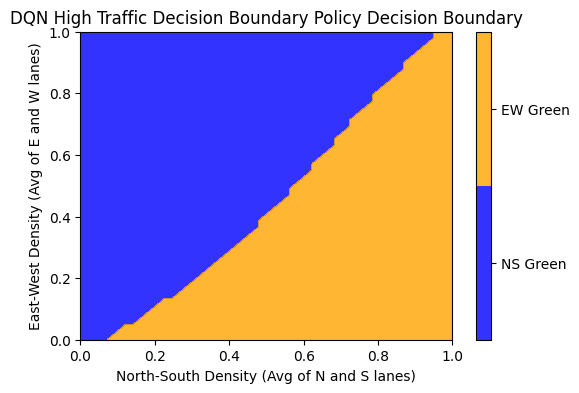

In [144]:
plot_decision_boundary("models/model_DQN_stationary_low_traffic", "DQN Low Traffic Decision Boundary", "results/dqn_low_traffic_decision_boundary.png", "DQN")
plot_decision_boundary("models/model_DQN_stationary_high_traffic", "DQN High Traffic Decision Boundary", "results/dqn_high_traffic_decision_boundary.png", "DQN")

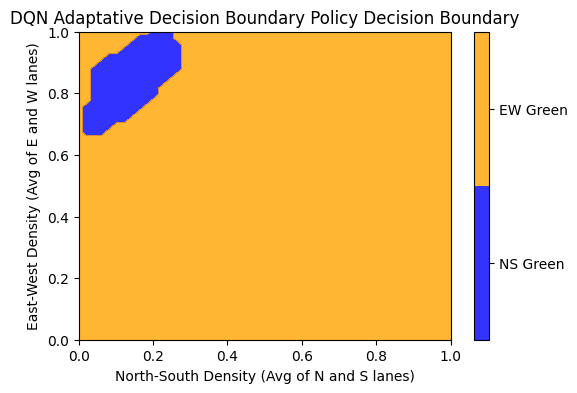

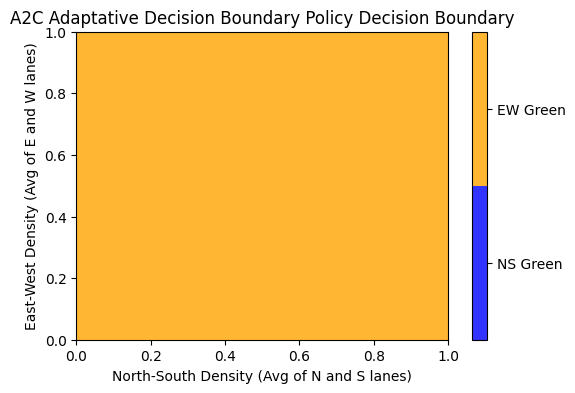

In [145]:
plot_decision_boundary("models/model_DQN_adaptative_random", "DQN Adaptative Decision Boundary", "results/dqn_adaptative_decision_boundary.png", "DQN")
plot_decision_boundary("models/model_A2C_adaptative_random", "A2C Adaptative Decision Boundary", "results/a2c_adaptative_decision_boundary.png")